## Plotting GRIB data

GRIB (GRIdded Binary) is the standard format for NWP (numerical weather
prediction) model output at operational centres such as ECMWF.
earthkit-plots reads GRIB files via earthkit-data's GRIB backend and
provides the same plotting API as for any other source type.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

### Loading a GRIB file

`ekd.from_source("sample", ...)` fetches a small ERA5 GRIB sample.  For
a local GRIB file use `ekd.from_source("file", "/path/to/file.grib")`.

In [2]:
grib = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib").to_fieldlist()
grib

### Inspecting the contents

`ls()` gives a summary of the fields in the file — useful when a GRIB
file contains multiple parameters, levels or time steps.

In [3]:
grib.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,1993-12-01,1993-12-01,0 days,0,surface,0,regular_ll


### Basic plot

Pass the earthkit-data FieldList directly to any plotting method.
GRIB files carry rich metadata (parameter name, units, level type,
valid time, …) which earthkit-plots uses automatically for titles,
unit conversion and style selection.

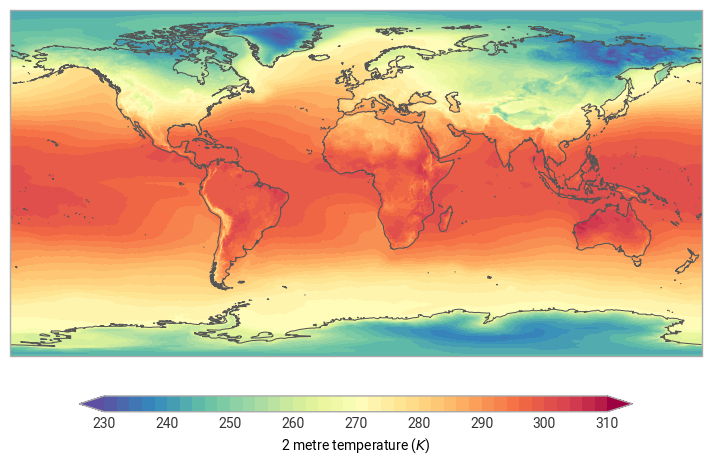

In [4]:
ekp.geo.plot(grib)

### Automatic style selection

`plot()` inspects the GRIB metadata and selects an appropriate style and
plot method automatically:

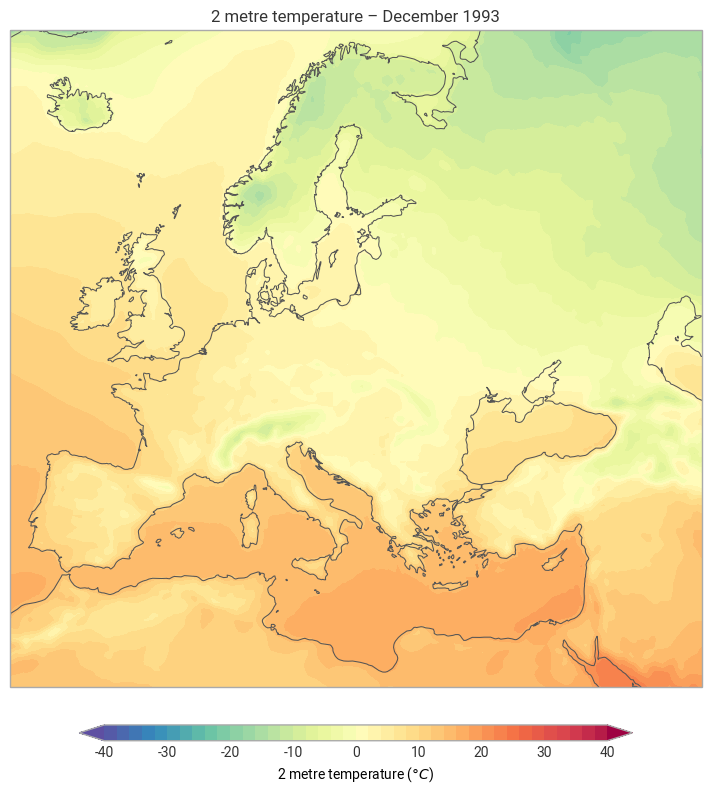

In [5]:
chart = ekp.Map(domain="Europe")
chart.plot(grib, units="celsius")
chart.legend()
chart.coastlines()
chart.title("{variable_name} – {time:%B %Y}")
chart.show()

### Format agnosticism

The plotting code above is essentially identical to the netCDF and xarray
examples — the only line that changes is how the data object is created:

```python
# GRIB
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

# netCDF
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc")

# xarray
data = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc").to_xarray()

# In every case, the plot call is identical:
chart = ekp.Map(domain="Europe")
chart.plot(data, units="celsius")
```

This format agnosticism is a deliberate design goal of earthkit-plots:
your visualisation code should not need to change just because your data
arrives in a different format.